In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as plt_sns
import sys
import json
from sklearn.metrics import roc_auc_score, recall_score, f1_score, average_precision_score, confusion_matrix, classification_report, precision_recall_curve

sys.path.append('../')
from src.core.preprocessor import prepare_german_data, prepare_credit_classification, prepare_give_me_some_credit, prepare_give_me_some_credit_grandmaster

plt.style.use('seaborn-v0_8-darkgrid') 

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
file_path = '../data/raw/German Credit Dataset/german_credit.csv'

X_train, X_test, y_train, y_test, feature_names = prepare_german_data(file_path)

print("DATA FACTORY REPORT")
print(f"Training Data Dimension (X_train): {X_train.shape} -> Note, the number of rows will definitely increase due to SMOTE")
print(f"Test Data Dimension (X_test): {X_test.shape} -> Must remain pure, untouched by SMOTE")
print(f"\nTarget Distribution (y_train) after SMOTE:")
print(y_train.value_counts())

DATA FACTORY REPORT
Training Data Dimension (X_train): (1120, 44) -> Note, the number of rows will definitely increase due to SMOTE
Test Data Dimension (X_test): (200, 44) -> Must remain pure, untouched by SMOTE

Target Distribution (y_train) after SMOTE:
class
1    560
0    560
Name: count, dtype: int64


In [4]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    
    auc = roc_auc_score(y_test, y_pred_prob)
    f1 = f1_score(y_test, y_pred)
    
    results.append({"Model": name, "AUC": auc, "F1-Score": f1})
    
    print(f"--- Performance Report: {name} ---")
    print(classification_report(y_test, y_pred))

df_results = pd.DataFrame(results)
display(df_results.sort_values(by="AUC", ascending=False))

--- Performance Report: Logistic Regression ---
              precision    recall  f1-score   support

           0       0.90      0.76      0.83       140
           1       0.59      0.80      0.68        60

    accuracy                           0.78       200
   macro avg       0.75      0.78      0.75       200
weighted avg       0.81      0.78      0.78       200

--- Performance Report: XGBoost ---
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       140
           1       0.58      0.50      0.54        60

    accuracy                           0.74       200
   macro avg       0.69      0.67      0.68       200
weighted avg       0.73      0.74      0.73       200



,Model,AUC,F1-Score
0,Logistic Regression,0.817024,0.680851
1,XGBoost,0.793214,0.535714


In [5]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

base_lr = LogisticRegression(random_state=42, max_iter=2000)

grid_search = GridSearchCV(
    estimator=base_lr,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_lr = grid_search.best_estimator_

y_pred_prob = best_lr.predict_proba(X_test)[:, 1]
y_pred = best_lr.predict(X_test)

auc = roc_auc_score(y_test, y_pred_prob)
f1 = f1_score(y_test, y_pred)

print("--- Hyperparameter Tuning Results ---")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation AUC: {grid_search.best_score_:.4f}")
print("\n--- Final Performance Report: Tuned Logistic Regression ---")
print(f"Test AUC: {auc:.4f}")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
--- Hyperparameter Tuning Results ---
Best Parameters: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best Cross-Validation AUC: 0.8252

--- Final Performance Report: Tuned Logistic Regression ---
Test AUC: 0.8171
              precision    recall  f1-score   support

           0       0.90      0.76      0.83       140
           1       0.59      0.80      0.68        60

    accuracy                           0.78       200
   macro avg       0.75      0.78      0.75       200
weighted avg       0.81      0.78      0.78       200



C:\Workspace\projects\ml\fintech-credit-risk-xai\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [6]:
file_path = '../data/raw/Credit Score Classification Dataset/train.csv'
X_train, X_test, y_train, y_test, feature_names = prepare_credit_classification(file_path)

models = {
    "Logistic Regression (Baseline)": LogisticRegression(random_state=42, max_iter=3000, solver='saga', n_jobs=-1),
    "XGBoost (Challenger)": XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    
    auc = roc_auc_score(y_test, y_pred_prob)
    f1 = f1_score(y_test, y_pred)
    
    results.append({"Model": name, "AUC": auc, "F1-Score": f1})
    
    print(f"--- Performance Report: {name} ---")
    print(classification_report(y_test, y_pred))

df_results = pd.DataFrame(results)
display(df_results.sort_values(by="AUC", ascending=False))

C:\Workspace\projects\ml\fintech-credit-risk-xai\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


--- Performance Report: Logistic Regression (Baseline) ---
              precision    recall  f1-score   support

           0       0.79      0.90      0.84     14200
           1       0.64      0.42      0.51      5800

    accuracy                           0.76     20000
   macro avg       0.71      0.66      0.68     20000
weighted avg       0.75      0.76      0.75     20000

--- Performance Report: XGBoost (Challenger) ---
              precision    recall  f1-score   support

           0       0.88      0.91      0.90     14200
           1       0.76      0.71      0.73      5800

    accuracy                           0.85     20000
   macro avg       0.82      0.81      0.82     20000
weighted avg       0.85      0.85      0.85     20000



,Model,AUC,F1-Score
1,XGBoost (Challenger),0.905199,0.733596
0,Logistic Regression (Baseline),0.779366,0.507057


In [7]:
file_path = '../data/raw/Give Me Some Credit/cs-training.csv'
X_train, X_test, y_train, y_test, feature_names = prepare_give_me_some_credit(file_path)

models = {
    "Logistic Regression (Baseline)": LogisticRegression(random_state=42, max_iter=2000, n_jobs=-1),
    "XGBoost (Challenger)": XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    
    auc = roc_auc_score(y_test, y_pred_prob)
    f1 = f1_score(y_test, y_pred)
    
    results.append({"Model": name, "AUC": auc, "F1-Score": f1})
    
    print(f"--- Performance Report: {name} ---")
    print(classification_report(y_test, y_pred))

df_results = pd.DataFrame(results)
display(df_results.sort_values(by="AUC", ascending=False))

C:\Workspace\projects\ml\fintech-credit-risk-xai\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


--- Performance Report: Logistic Regression (Baseline) ---
              precision    recall  f1-score   support

           0       0.97      0.76      0.85     27995
           1       0.17      0.68      0.27      2005

    accuracy                           0.76     30000
   macro avg       0.57      0.72      0.56     30000
weighted avg       0.92      0.76      0.81     30000

--- Performance Report: XGBoost (Challenger) ---
              precision    recall  f1-score   support

           0       0.95      0.97      0.96     27995
           1       0.43      0.28      0.34      2005

    accuracy                           0.93     30000
   macro avg       0.69      0.63      0.65     30000
weighted avg       0.92      0.93      0.92     30000



,Model,AUC,F1-Score
1,XGBoost (Challenger),0.842367,0.341803
0,Logistic Regression (Baseline),0.797846,0.272854


--- THRESHOLD OPTIMIZATION RESULTS ---
Optimal Threshold (Max F1): 0.3800
Maximum F1-Score: 0.3966

--- XGBoost Performance @ Threshold 0.3800 ---
              precision    recall  f1-score   support

           0       0.96      0.95      0.95     27995
           1       0.37      0.43      0.40      2005

    accuracy                           0.91     30000
   macro avg       0.66      0.69      0.67     30000
weighted avg       0.92      0.91      0.92     30000



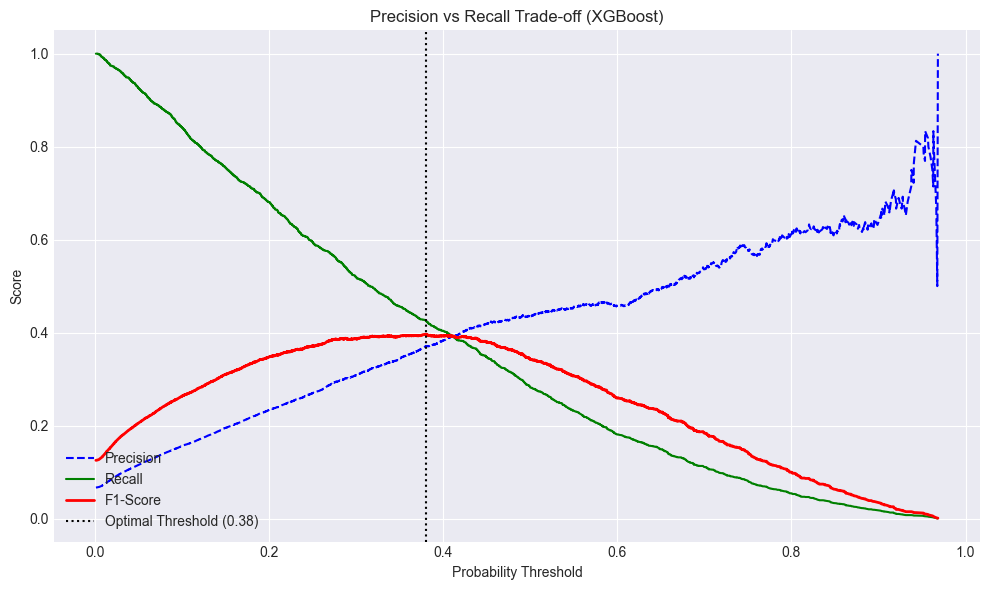

In [8]:
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1)
xgb_model.fit(X_train, y_train)

y_pred_prob = xgb_model.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_prob)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print("--- THRESHOLD OPTIMIZATION RESULTS ---")
print(f"Optimal Threshold (Max F1): {best_threshold:.4f}")
print(f"Maximum F1-Score: {best_f1:.4f}")

y_pred_optimal = (y_pred_prob >= best_threshold).astype(int)

print(f"\n--- XGBoost Performance @ Threshold {best_threshold:.4f} ---")
print(classification_report(y_test, y_pred_optimal))

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision')
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall')
plt.plot(thresholds, f1_scores[:-1], 'r-', linewidth=2, label='F1-Score')
plt.axvline(x=best_threshold, color='k', linestyle=':', label=f'Optimal Threshold ({best_threshold:.2f})')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall Trade-off (XGBoost)')
plt.legend(loc='lower left')
plt.tight_layout()
plt.savefig('threshold_optimization.png', dpi=150)
plt.show()

In [9]:
file_path = '../data/raw/Give Me Some Credit/cs-training.csv'
X_train, X_test, y_train, y_test, feature_names = prepare_give_me_some_credit_grandmaster(file_path)

imbalance_ratio = (len(y_train) - sum(y_train)) / sum(y_train)

xgb_gm = XGBClassifier(
    random_state=42, 
    eval_metric='logloss', 
    scale_pos_weight=imbalance_ratio,
    max_depth=4,
    learning_rate=0.05,
    n_estimators=300,
    n_jobs=-1
)

xgb_gm.fit(X_train, y_train)

y_pred_prob = xgb_gm.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_pred_prob)
print(f"--- Grandmaster Model AUC: {auc:.4f} ---")

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_prob)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

y_pred_optimal = (y_pred_prob >= best_threshold).astype(int)

print(f"\n--- Performance @ Optimized Threshold {best_threshold:.4f} ---")
print(classification_report(y_test, y_pred_optimal))

--- Grandmaster Model AUC: 0.8687 ---

--- Performance @ Optimized Threshold 0.7885 ---
              precision    recall  f1-score   support

           0       0.96      0.95      0.96     27995
           1       0.41      0.49      0.45      2005

    accuracy                           0.92     30000
   macro avg       0.69      0.72      0.70     30000
weighted avg       0.93      0.92      0.92     30000



In [10]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

joblib.dump(xgb_gm, '../models/xgboost_grandmaster.joblib')

joblib.dump(feature_names, '../models/feature_names.joblib')

print("Model dan daftar fitur berhasil disimpan di direktori ../models/")

Model dan daftar fitur berhasil disimpan di direktori ../models/


In [13]:
def calculate_and_save_metrics(y_true, y_pred, y_prob, filepath="../metrics.json"):
    roc_auc = roc_auc_score(y_true, y_prob)
    gini = (2 * roc_auc) - 1
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    pr_auc = average_precision_score(y_true, y_prob)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    metrics = {
        "ROC_AUC": round(roc_auc, 4),
        "Gini_Coefficient": round(gini, 4),
        "Recall": round(recall, 4),
        "F1_Score": round(f1, 4),
        "PR_AUC": round(pr_auc, 4),
        "False_Negatives": int(fn),
        "False_Positives": int(fp)
    }

    print(json.dumps(metrics, indent=4))

    with open(filepath, "w") as f:
        json.dump(metrics, f, indent=4)

    return metrics

In [14]:
y_prob_gm = xgb_gm.predict_proba(X_test)[:, 1]

threshold_optimal = 0.7885
y_pred_gm = (y_prob_gm >= threshold_optimal).astype(int)

saved_metrics = calculate_and_save_metrics(
    y_true=y_test, 
    y_pred=y_pred_gm, 
    y_prob=y_prob_gm, 
    filepath="../metrics.json"
)

{
    "ROC_AUC": 0.8687,
    "Gini_Coefficient": 0.7374,
    "Recall": 0.4923,
    "F1_Score": 0.4503,
    "PR_AUC": 0.4067,
    "False_Negatives": 1018,
    "False_Positives": 1392
}
